In [1]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from scipy.signal import find_peaks
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
from lightkurve import LightCurve
import lightkurve as lk

search_result = search_lightcurve("AU Mic") 
lc2min = search_result[8].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

In [2]:
vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.204,2041.404],
    [2047.4961,2047.6481],
    [2051.4334,2051.6652],
    [2053.416,2053.715],
    [2058.108,2058.276],
    [2037.663,2037.787],
    [2058.8291,2058.8768],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.26492, 2039.26775],
    [2039.34872, 2039.35791],
    [2039.82051, 2039.84413],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2051.438,2051.772],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.5068, 2047.6352],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.8243, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.8290, 2058.8695],
    [2059.10883, 2059.11091],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109]
]

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)

valores = [
    [2036.7051, 2036.71029],
    [2037.4387, 2037.4854],
    [2037.6680, 2037.7583],
    [2037.71922, 2037.73284],
    [2039.1808, 2039.19745],
    [2039.26492, 2039.26847],
    [2039.34872, 2039.3705],
    [2039.80907, 2039.8322],
    [2040.0282, 2040.0972],
    [2041.1855, 2041.3798],
    [2042.48388, 2042.5330],
    [2047.21322, 2047.2394],
    [2047.34522, 2047.3719],
    [2047.5004, 2047.51074],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.74298],
    [2049.6730, 2049.8201],
    [2050.78041, 2050.7841],
    [2050.8560, 2050.8704],
    [2050.31549, 2050.31673],
    [2051.4376, 2051.6327],
    [2053.08171, 2053.08283],
    [2053.4250, 2053.5674],
    [2055.8991, 2055.9414],
    [2056.26941, 2056.27359],
    [2056.82718,2057.1055],
    [2057.79801, 2057.80547],
    [2058.1318, 2058.2471],
    [2058.24047, 2058.24378],
    [2058.83466, 2058.84524],
    [2059.10867, 2059.11091],
    [2059.5464, 2059.5836],
    [2059.6774, 2059.67974],
    [2056.68717, 2056.69244]
]

valores_true = [False]*len(x2min)

with open("setor27_2Min_f.txt", "w") as file:
    for vetor in valores:
        file.write(f"{vetor[0]} {vetor[1]}\n")

valores_true = [False]*len(x2min)

for j in range(len(x2min)):
    for i in range(len(valores)):
        if (x2min[j]>=valores[i][0]) and (x2min[j]<=valores[i][1]):
            valores_true[j] = True

mascara_1 = np.array(valores_true)

In [3]:
#flcd_d[1]

flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)

flcd = flcd

tempo_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
fluxo_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)


#Recortando e ajeitando ainda mais a normalização 
xdefinitivo2 = []
ydefinitivo2 = []
for j in range(len(y2min)):
    if 2047.4854 < x2min[j] < 2047.692002:
        xdefinitivo2.append(x2min[j])
        ydefinitivo2.append(y2min[j])

xdefinitivo2 = np.array(xdefinitivo2)
ydefinitivo2 = np.array(ydefinitivo2)


vetores1 = [
    [2047.6266, 2047.6796]
]
vetor_true1 = [False]*len(xdefinitivo2)

for j in range(len(xdefinitivo2)):
    for i in range(len(vetores1)):
        if (xdefinitivo2[j]>=vetores1[i][0]) and (xdefinitivo2[j]<=vetores1[i][1]):
            vetor_true1[j] = True

mascara1 = np.array(vetor_true1)


lc =  LightCurve(time=xdefinitivo2, flux=ydefinitivo2)
flcd2 = lc.flatten(window_length=30, polyorder=1, return_trend=False, break_tolerance=10, niters=2, sigma=2.5, mask=mascara1)


detrended_lc = flcd2

tempo_detrend1 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend1 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

#################################################################################################################
#Recortando e ajeitando ainda mais a normalização 
xdefinitivo3 = []
ydefinitivo3 = []
for j in range(len(y2min)):
    if 2058.7802 < x2min[j] < 2058.88527:
        xdefinitivo3.append(x2min[j])
        ydefinitivo3.append(y2min[j])

xdefinitivo3 = np.array(xdefinitivo3)
ydefinitivo3 = np.array(ydefinitivo3)

vetores2 = [
    [2058.8314,2058.8763]
]
vetor_true2 = [False]*len(xdefinitivo3)

for j in range(len(xdefinitivo3)):
    for i in range(len(vetores2)):
        if (xdefinitivo3[j]>=vetores2[i][0]) and (xdefinitivo3[j]<=vetores2[i][1]):
            vetor_true2[j] = True

mascara3 = np.array(vetor_true2)

lc2 =  LightCurve(time=xdefinitivo3, flux=ydefinitivo3)
flcd3 = lc2.flatten(window_length=30, polyorder=1, return_trend=False, break_tolerance=10, niters=4, sigma=2.5, mask=mascara3)

detrended_lc = flcd3

tempo_detrend3 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend3 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)
#########################################################################################################################################################################
xdefinitivo4 = []
ydefinitivo4 = []
for j in range(len(y2min)):
    if 2059.02678 < x2min[j] < 2059.1702:
        xdefinitivo4.append(x2min[j])
        ydefinitivo4.append(y2min[j])

xdefinitivo4 = np.array(xdefinitivo4)
ydefinitivo4 = np.array(ydefinitivo4)

vetores6 = [
    [2059.0928,2059.1565]
]
vetor_true6 = [False]*len(xdefinitivo4)

for j in range(len(xdefinitivo4)):
    for i in range(len(vetores6)):
        if (xdefinitivo4[j]>=vetores6[i][0]) and (xdefinitivo4[j]<=vetores6[i][1]):
            vetor_true6[j] = True

mascara6 = np.array(vetor_true6)


lc4 =  LightCurve(time=xdefinitivo4, flux=ydefinitivo4)
flcd4 = lc4.flatten(window_length=35, polyorder=1, return_trend=False, break_tolerance=7, niters=1, sigma=2.5, mask=mascara6)

detrended_lc = flcd4

tempo_detrend4 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend4 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

##############################################################################################################################################################

xdefinitivo5 = []
ydefinitivo5 = []
for j in range(len(y2min)):
    if 2036.8961 < x2min[j] < 2037.0935:
        xdefinitivo5.append(x2min[j])
        ydefinitivo5.append(y2min[j])


xdefinitivo5 = np.array(xdefinitivo5)
ydefinitivo5 = np.array(ydefinitivo5)

vetores3 = [
    [2036.9702,2037.0661]
]
vetor_true3 = [False]*len(xdefinitivo5)

for j in range(len(xdefinitivo5)):
    for i in range(len(vetores3)):
        if (xdefinitivo5[j]>=vetores3[i][0]) and (xdefinitivo5[j]<=vetores3[i][1]):
            vetor_true3[j] = True

mascara5 = np.array(vetor_true3)


lc5 =  LightCurve(time=xdefinitivo5, flux=ydefinitivo5)
flcd5 = lc5.flatten(window_length=50, polyorder=1, return_trend=False, break_tolerance=10, niters=2, sigma=2.5, mask=mascara5)

detrended_lc = flcd5

tempo_detrend5 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend5 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

########### O FOR PARA O CORTE DOS VALORES QUE ESTÃO COM NORMALIZAÇÃO RUIM E ADICIONAR NA NORMALIZAÇÃO MELHOR######################################################
count = 0
count1 = 0
count3 = 0
count4 = 0
for j in range(len(tempo_detrend)):
    if tempo_detrend[j]>=2047.4854 and  tempo_detrend[j]<=2047.692002:
       fluxo_detrend[j]= fluxo_detrend1[count]
       tempo_detrend[j]= tempo_detrend1[count]
       count = count + 1
    if tempo_detrend[j]>=2058.7802 and  tempo_detrend[j]<=2058.88527:
       fluxo_detrend[j]= fluxo_detrend3[count1]
       tempo_detrend[j]= tempo_detrend3[count1]
       count1 = count1 + 1
    if tempo_detrend[j]>= 2036.8961 and  tempo_detrend[j]<= 2037.0935:
       fluxo_detrend[j]= fluxo_detrend5[count3]
       tempo_detrend[j]= tempo_detrend5[count3]
       count3 = count3 + 1
    if tempo_detrend[j]>= 2059.02678 and  tempo_detrend[j]<= 2059.1702:
       fluxo_detrend[j]= fluxo_detrend4[count4]
       tempo_detrend[j]= tempo_detrend4[count4]
       count4 = count4 + 1


In [4]:
############ PARA CALCULAR A MÉDIA E O DESVIO COM RUIDO ########################################################################################################################   
x_detrend = []
y_detrend = []
for j in range(len(mascara_1)):
    if mascara_1[j] == False:
        y_detrend.append(fluxo_detrend[j])
        x_detrend.append(tempo_detrend[j])

x_detrend = np.array(x_detrend)
y_detrend = np.array(y_detrend)


y_mean = np.mean(y_detrend)
#Media para todos os pontos do eixo x, para apresentar no grafico 
#y_mean2 = [y_mean for i in range(len(y))]
y_mean2 = [y_mean]*len(y_detrend)
#Calculo do desvio padrao dos dados
desvio = (np.std(y_detrend))
print(y_mean)
#Media mais desvio padrao
med_desv = y_mean2+desvio

#Corte nos valores de média+ 2*sigma

med_desv2 = y_mean + (2*desvio)
med_desv3 = y_mean - (2*desvio)
xdefinitivo = []
ydefinitivo = []
for j in range(len(y_detrend)):
    if y_detrend[j] < med_desv2 and y_detrend[j]>med_desv3:
        ydefinitivo.append(y_detrend[j])
        xdefinitivo.append(x_detrend[j])

xdefinitivo = np.array(xdefinitivo)
ydefinitivo = np.array(ydefinitivo)

#Calculo novo da média e do desvio padrão do ruido 
y_m = np.mean(ydefinitivo)
y_m2 = [y_m]*len(ydefinitivo)
desvio2 = (np.std(ydefinitivo))
med = y_m2 + desvio2
med2 = y_m + 3* desvio2

1.0000729597401639


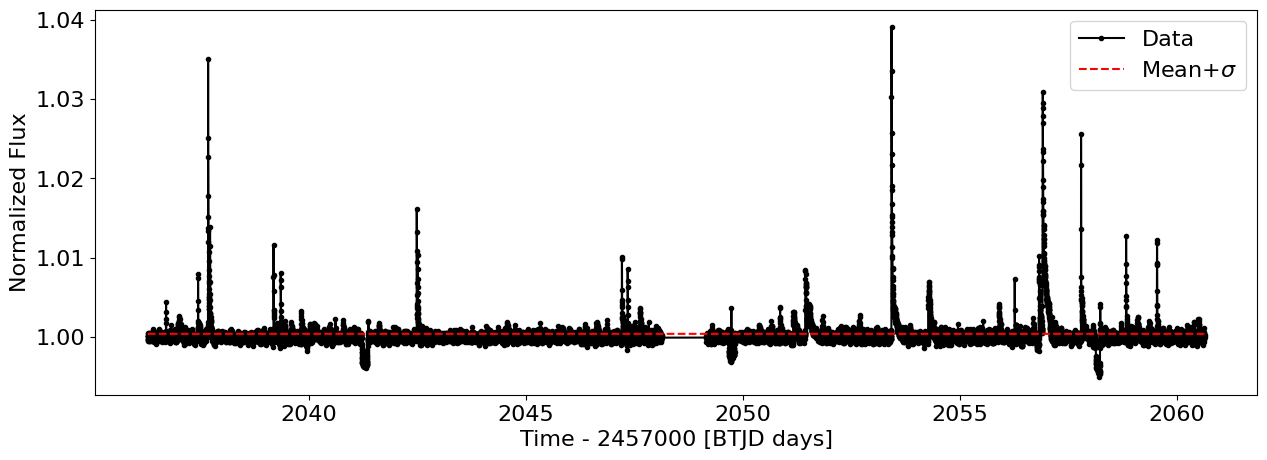

In [8]:
plt.rcParams['font.size'] = 16
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plote os dados
data_line = ax.plot(tempo_detrend, fluxo_detrend, marker='.', color='black', label='Data')

# Plote os picos
#ax.plot(tempo_detrend[peaks], fluxo_detrend[peaks], 'bx', label='Picos')

# Plote a linha tracejada da média
ax.plot(xdefinitivo, med, label='Mean+$\sigma$', linestyle='--', color='red')

#@ax.plot(xdefinitivo, y_m2, label='Média', linestyle='--', color='blue')
# Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux', rasterized=True)
plt.show()